In [21]:
# This Python 3 environment comes with many helpful analytics libraries installed
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import warnings
warnings.filterwarnings("ignore", category=FutureWarning, module="seaborn")

# Exploratory Data Analysis: Solar Power Generation Prediction

This project explores a solar power generation dataset in order to prepare it for a supervised learning model. The goal is to understand how environmental conditions influence solar energy production and identify features that may help predict solar power output.

This analysis is also driven by a personal goal of eventually relying on an off-grid solar power system. Following the approach from my previous exploratory data analysis lab, where I focused on predicting energy consumption, I now want to extend that understanding to the production side by building a model that can predict solar power generation based on various environmental factors.

Establishing a clear understanding of how these variables affect solar output will be important for making informed decisions about future system design. In particular, this analysis can help guide the type of solar setup I should pursue, including considerations such as system size, expected power output, and the potential effects of environmental conditions on overall performance in a real-world off-grid scenario.

## 1. Dataset Introduction

This dataset contains solar power generation data collected from photovoltaic plants along with environmental measurements such as irradiation and temperature. These variables influence how much electrical energy solar panels can produce at any given time.

The dataset includes measurements such as:

- Solar irradiation
- Ambient temperature
- Module (panel) temperature
- Time-based measurements
- Power generation values

### Target Variable

The target feature for this project is:

**AC_POWER**

AC_POWER represents the usable electrical power produced by the solar plant after conversion through the inverter.

### Problem Type

This will be treated as a **regression problem**, where the goal is to predict the amount of solar power generated based on environmental conditions and time-based factors.

In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df_gen = pd.read_csv('Plant_1_Generation_Data.csv')
df_weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

In [4]:
df = pd.merge(df_gen, df_weather, on='DATE_TIME', how='inner')

In [5]:
df.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION


In [6]:
df_gen = pd.read_csv('Plant_1_Generation_Data.csv')

df_gen.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD
0,15-05-2020 00:00,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0
1,15-05-2020 00:00,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0
2,15-05-2020 00:00,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0
3,15-05-2020 00:00,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0
4,15-05-2020 00:00,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0


In [7]:
df_weather = pd.read_csv('Plant_1_Weather_Sensor_Data.csv')

df_weather.head()

,DATE_TIME,PLANT_ID,SOURCE_KEY,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15 00:00:00,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15 00:15:00,4135001,HmiyD2TTLFNqkNe,25.084589,22.761668,0.0
2,2020-05-15 00:30:00,4135001,HmiyD2TTLFNqkNe,24.935753,22.592306,0.0
3,2020-05-15 00:45:00,4135001,HmiyD2TTLFNqkNe,24.846130,22.360852,0.0
4,2020-05-15 01:00:00,4135001,HmiyD2TTLFNqkNe,24.621525,22.165423,0.0


## 2. Data Loading and Initial Inspection

In this section, the solar power generation dataset and the corresponding weather dataset are loaded into the notebook. These datasets contain information about power output and environmental conditions, respectively.

The two datasets are then merged on the DATE_TIME column to combine power generation data with weather data into a single dataframe. This allows for a unified analysis of how environmental factors influence solar energy production.

Initial inspection of the datasets is performed using `.head()` to understand the structure, features, and overall layout of the data before proceeding with further analysis.

In [8]:
# Correct date parsing

df_gen['DATE_TIME'] = pd.to_datetime(df_gen['DATE_TIME'], dayfirst=True)
df_weather['DATE_TIME'] = pd.to_datetime(df_weather['DATE_TIME'])

# Merge
df = pd.merge(df_gen, df_weather, on='DATE_TIME', how='inner')

These datasets must be merged because the generation data contains AC_POWER (the target variable) and the weather data contains IRRADIATION and temperature. Predictive features come from weather, but the target comes from generation

In [9]:
df = pd.merge(df_gen, df_weather, on='DATE_TIME')

df.head()

,DATE_TIME,PLANT_ID_x,SOURCE_KEY_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,SOURCE_KEY_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
0,2020-05-15,4135001,1BY6WEcLGh8j5v7,0.0,0.0,0.0,6259559.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
1,2020-05-15,4135001,1IF53ai7Xc0U56Y,0.0,0.0,0.0,6183645.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
2,2020-05-15,4135001,3PZuoBAID5Wc2HD,0.0,0.0,0.0,6987759.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
3,2020-05-15,4135001,7JYdWkrLSPkdwr4,0.0,0.0,0.0,7602960.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0
4,2020-05-15,4135001,McdE0feGgRqW7Ca,0.0,0.0,0.0,7158964.0,4135001,HmiyD2TTLFNqkNe,25.184316,22.857507,0.0


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 68774 entries, 0 to 68773
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   DATE_TIME            68774 non-null  datetime64[ns]
 1   PLANT_ID_x           68774 non-null  int64         
 2   SOURCE_KEY_x         68774 non-null  object        
 3   DC_POWER             68774 non-null  float64       
 4   AC_POWER             68774 non-null  float64       
 5   DAILY_YIELD          68774 non-null  float64       
 6   TOTAL_YIELD          68774 non-null  float64       
 7   PLANT_ID_y           68774 non-null  int64         
 8   SOURCE_KEY_y         68774 non-null  object        
 9   AMBIENT_TEMPERATURE  68774 non-null  float64       
 10  MODULE_TEMPERATURE   68774 non-null  float64       
 11  IRRADIATION          68774 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(2), object(2)
memory usage: 6.3+ MB


In [11]:
df.shape

(68774, 12)

In [12]:
df.describe()

,DATE_TIME,PLANT_ID_x,DC_POWER,AC_POWER,DAILY_YIELD,TOTAL_YIELD,PLANT_ID_y,AMBIENT_TEMPERATURE,MODULE_TEMPERATURE,IRRADIATION
count,68774,68774.0,68774.000000,68774.000000,68774.000000,6.877400e+04,68774.0,68774.000000,68774.000000,68774.000000
mean,2020-06-01 08:02:38.161514240,4135001.0,3147.177450,307.778375,3295.834644,6.978728e+06,4135001.0,25.558521,31.244997,0.232305
min,2020-05-15 00:00:00,4135001.0,0.000000,0.000000,0.000000,6.183645e+06,4135001.0,20.398505,18.140415,0.000000
25%,2020-05-24 00:33:45,4135001.0,0.000000,0.000000,0.000000,6.512007e+06,4135001.0,22.724491,21.123944,0.000000
50%,2020-06-01 14:15:00,4135001.0,428.571429,41.450000,2658.473214,7.146685e+06,4135001.0,24.670178,24.818984,0.031620
75%,2020-06-09 20:00:00,4135001.0,6365.468750,623.561161,6274.000000,7.268751e+06,4135001.0,27.960429,41.693659,0.454880
max,2020-06-17 23:45:00,4135001.0,14471.125000,1410.950000,9163.000000,7.846821e+06,4135001.0,35.252486,65.545714,1.221652
std,NaN,0.0,4036.441826,394.394865,3145.220597,4.162707e+05,0.0,3.361300,12.308283,0.301948


## 3. Missing Data Analysis

Before proceeding with further analysis, it is important to evaluate whether the dataset contains any missing values. Missing data can impact both exploratory analysis and the performance of machine learning models if not properly handled.

In [13]:
df.isnull().sum()

DATE_TIME              0
PLANT_ID_x             0
SOURCE_KEY_x           0
DC_POWER               0
AC_POWER               0
DAILY_YIELD            0
TOTAL_YIELD            0
PLANT_ID_y             0
SOURCE_KEY_y           0
AMBIENT_TEMPERATURE    0
MODULE_TEMPERATURE     0
IRRADIATION            0
dtype: int64

The results show that there are no missing values present in any of the columns in the dataset.

This indicates that the dataset is complete and does not require additional preprocessing steps such as imputation or removal of missing data. As a result, we can proceed confidently with further analysis and model development.

## 4. Data Preparation

Several preprocessing steps were performed to prepare the dataset for analysis and future predictive modeling.

First, the `DATE_TIME` column was converted from a string format to a datetime format. This allows time-based features to be extracted and enables analysis of how solar power generation changes throughout the day.

Next, the **hour of day** was extracted from the timestamp. Solar energy production follows predictable daily cycles, typically increasing during the morning, peaking around midday, and declining toward evening.

A **daylight indicator** variable was also created using the irradiation measurement. When irradiation is greater than zero, sunlight is reaching the panels and solar generation is possible. When irradiation is zero, it indicates nighttime conditions where solar power production does not occur.

Finally, a **temperature difference feature** was created by subtracting ambient temperature from module temperature. Solar panels typically operate at higher temperatures than the surrounding air when exposed to sunlight, and this difference can influence panel efficiency and energy production.

In [14]:
df = df.drop(columns=['PLANT_ID_x','PLANT_ID_y','SOURCE_KEY_x','SOURCE_KEY_y'], errors='ignore')

The above drops the column if it exists, otherwise it does nothing.

In [15]:
df['DATE_TIME'] = pd.to_datetime(df['DATE_TIME'])

In [16]:
df['Hour'] = df['DATE_TIME'].dt.hour

In [17]:
df['IsDaylight'] = (df['IRRADIATION'] > 0).astype(int)

In [18]:
df['Temp_Difference'] = df['MODULE_TEMPERATURE'] - df['AMBIENT_TEMPERATURE']

## 5. Data Visualizations

The following visualizations were created to explore the relationships between environmental conditions and solar power generation. Because the target variable for this project is **AC_POWER**, the visual analysis focuses on identifying which features appear most useful for predicting solar output.

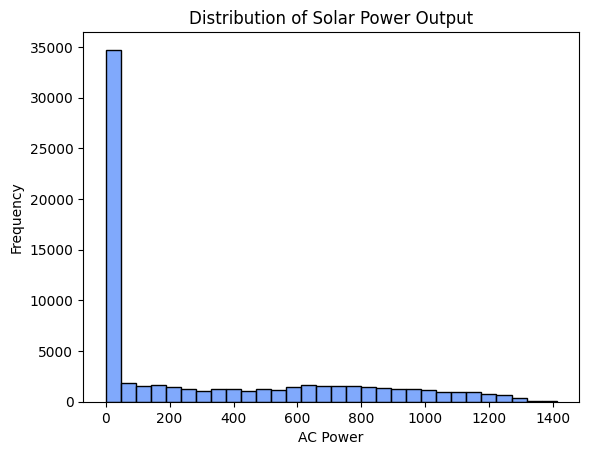

In [22]:
df['AC_POWER'] = df['AC_POWER'].replace([np.inf, -np.inf], np.nan)
sns.histplot(df['AC_POWER'], bins=30)
plt.title("Distribution of Solar Power Output")
plt.xlabel("AC Power")
plt.ylabel("Frequency")
plt.show()

### Solar Irradiation vs AC Power

Solar irradiation is one of the most important environmental variables affecting solar energy generation. Because solar panels depend on incoming sunlight, this visualization helps evaluate whether higher irradiation levels correspond to higher AC power output.

A scatterplot is useful here because it shows the relationship between two continuous variables and allows us to identify overall trends, clustering behavior, and possible nonlinear patterns.

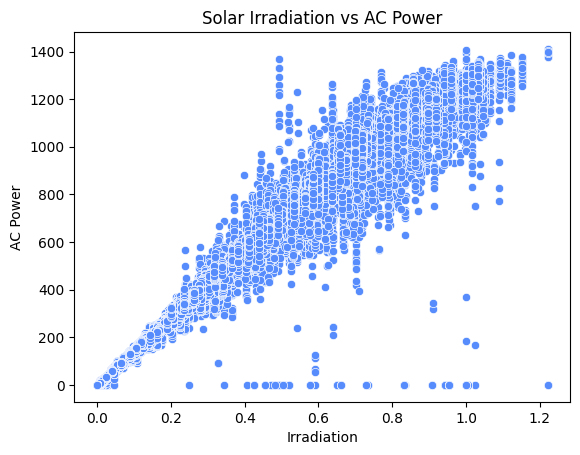

In [23]:
sns.scatterplot(x='IRRADIATION', y='AC_POWER', data=df)
plt.title("Solar Irradiation vs AC Power")
plt.xlabel("Irradiation")
plt.ylabel("AC Power")
plt.show()

The scatterplot shows a strong positive relationship between solar irradiation and AC power. As irradiation increases, AC power output also increases, which is expected because solar panels generate more electricity when exposed to greater sunlight intensity.

A dense concentration of points appears near the lower-left corner, indicating many time periods with little to no irradiation and correspondingly low AC power output. This likely reflects nighttime or very low-light conditions.

As irradiation rises, AC power generally increases, though the relationship may not be perfectly linear across the full range. Some spread in the higher-irradiation region suggests that other variables, such as module temperature or system efficiency, may also influence final AC output.

Overall, this visualization suggests that irradiation is likely one of the strongest predictors of solar power generation and should be considered an important feature for future machine learning modeling.

### Module Temperature vs AC Power

Module temperature may influence solar panel performance because panel efficiency can change as temperature rises. This visualization helps examine whether higher module temperatures are associated with changes in AC power output.

By using a scatterplot, we can observe the direction and strength of the relationship while also identifying variation across operating conditions.

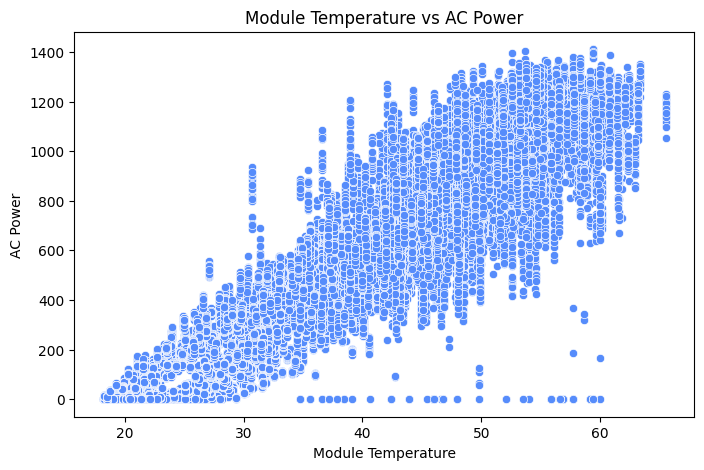

In [24]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='MODULE_TEMPERATURE', y='AC_POWER', data=df)
plt.title("Module Temperature vs AC Power")
plt.xlabel("Module Temperature")
plt.ylabel("AC Power")
plt.show()

The scatterplot shows a positive relationship between module temperature and AC power, although this pattern is likely influenced by sunlight exposure. As module temperature increases, AC power also tends to increase, which is consistent with the fact that solar panels usually become hotter during periods of stronger solar irradiation.

However, this relationship should be interpreted carefully. Higher module temperature does not necessarily mean temperature itself improves performance. Instead, both module temperature and AC power may rise together because they are driven by the same underlying factor: stronger sunlight.

The spread in the data suggests that module temperature alone does not fully explain AC power output. This indicates that it may be useful in modeling, but probably alongside other important variables such as irradiation and ambient temperature.

### Ambient Temperature vs AC Power

Ambient temperature represents the surrounding environmental temperature near the solar panels. While temperature itself does not generate electricity, it may influence solar panel efficiency and operating conditions.

This visualization explores whether changes in ambient temperature correspond with changes in AC power output.

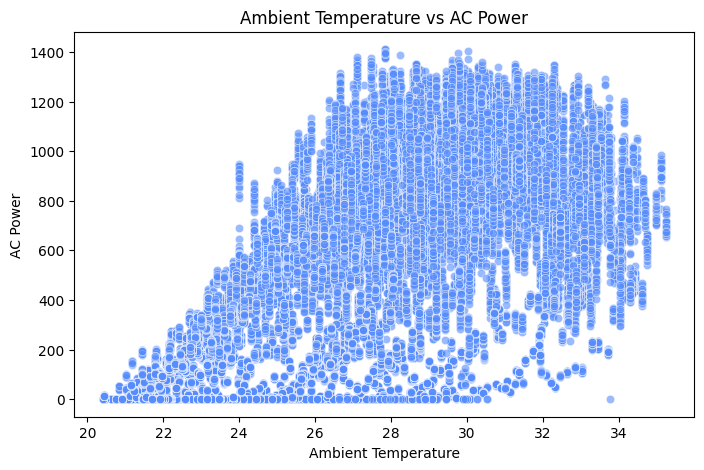

In [25]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='AMBIENT_TEMPERATURE', y='AC_POWER', alpha=0.6)
plt.title('Ambient Temperature vs AC Power')
plt.xlabel('Ambient Temperature')
plt.ylabel('AC Power')
plt.show()

The scatterplot shows a moderate positive relationship between ambient temperature and AC power output. Higher AC power values tend to occur at higher ambient temperatures.

However, this relationship is likely influenced by solar irradiation, since warmer temperatures typically occur during periods of stronger sunlight.

This pattern is expected because solar panels absorb sunlight and convert part of that energy into electricity while the remainder becomes heat. As a result, higher sunlight exposure typically leads to higher panel temperatures.

The upward trend suggests that module temperature is strongly influenced by irradiation levels.

### AC Power by Hour of Day

Solar power production follows a daily pattern driven by the position of the sun. By analyzing AC power output across hours of the day, we can observe how generation changes throughout the daylight cycle.

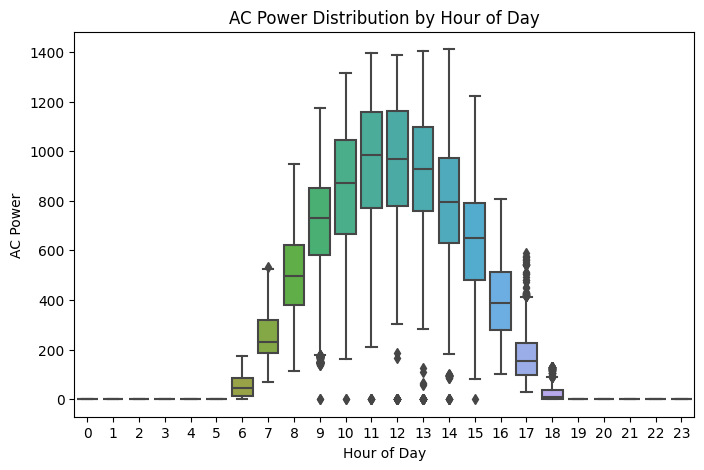

In [26]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df, x='Hour', y='AC_POWER')
plt.title('AC Power Distribution by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('AC Power')
plt.show()

The boxplot shows that AC power production follows a clear daily pattern. Power generation is very low during early morning and nighttime hours and increases significantly during midday.

The highest power output typically occurs around midday when the sun is highest in the sky, and solar irradiation is strongest.

This pattern confirms that time of day plays a major role in solar power production and may be an important feature for predictive modeling.

### AC Power During Daylight vs Night

The IsDaylight feature was engineered based on solar irradiation values. It distinguishes between periods when sunlight is present and when it is absent.

This visualization compares AC power generation between daylight and non-daylight periods.

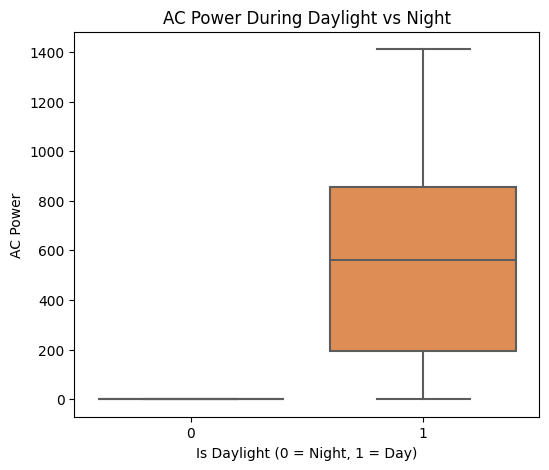

In [27]:
plt.figure(figsize=(6,5))
sns.boxplot(data=df, x='IsDaylight', y='AC_POWER')
plt.title('AC Power During Daylight vs Night')
plt.xlabel('Is Daylight (0 = Night, 1 = Day)')
plt.ylabel('AC Power')
plt.show()

The boxplot clearly shows that AC power is significantly higher during daylight periods compared to nighttime periods.

During nighttime (IsDaylight = 0), AC power values are close to zero because solar panels cannot generate electricity without sunlight.

During daylight (IsDaylight = 1), AC power increases substantially, confirming that solar irradiation is the primary driver of power generation.

### Temperature Difference vs AC Power

Temperature difference represents the difference between module temperature and ambient temperature. This feature can indicate how much the solar panel heats up compared to the surrounding air.

Higher temperature differences may occur during periods of strong sunlight.

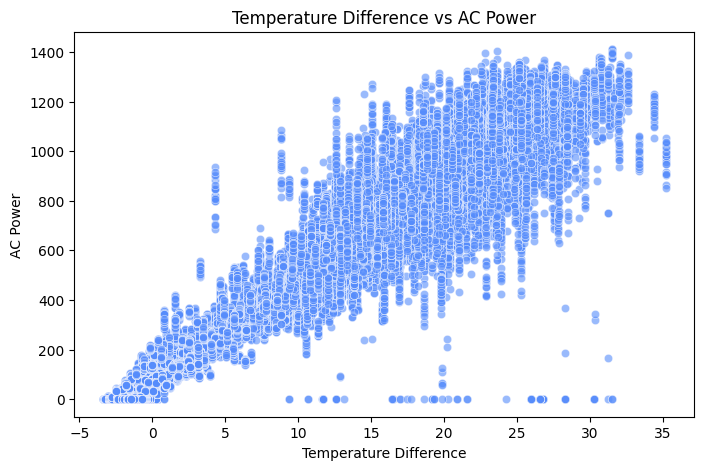

In [28]:
plt.figure(figsize=(8,5))
sns.scatterplot(data=df, x='Temp_Difference', y='AC_POWER', alpha=0.6)
plt.title('Temperature Difference vs AC Power')
plt.xlabel('Temperature Difference')
plt.ylabel('AC Power')
plt.show()

The scatterplot shows that higher temperature differences tend to occur alongside higher AC power output.

This relationship likely occurs because strong solar irradiation increases both the electrical output of the panels and the amount of heat absorbed by the module surface.

Although temperature difference may not directly cause higher power output, it may still provide useful information for modeling solar panel performance.

### Feature Correlation Heatmap

A correlation heatmap helps identify relationships between variables in the dataset. Strong correlations may indicate important predictors for solar power generation.

This visualization shows the pairwise correlation between numerical features.

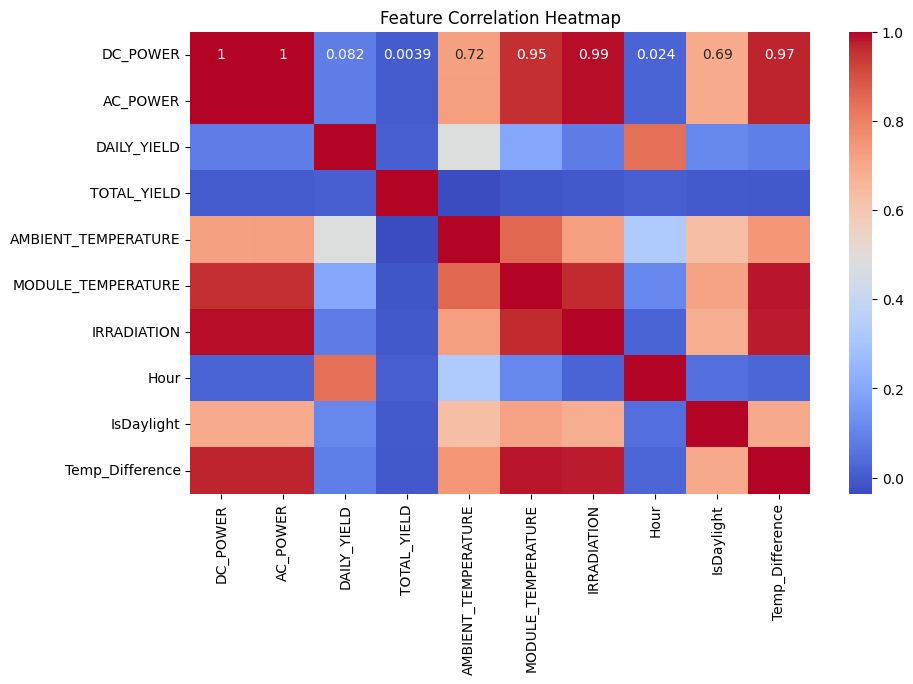

In [29]:
plt.figure(figsize=(10,6))
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

The correlation heatmap highlights the relationships between numerical variables in the dataset.

AC power shows the strongest positive correlation with solar irradiation, confirming earlier visualizations that sunlight intensity is the primary driver of power generation.

Module temperature also shows a positive relationship with both irradiation and AC power, suggesting that panel temperature rises during periods of strong sunlight.

This reinforces earlier findings from the scatterplots, where irradiation showed the strongest visual relationship with AC power.

Overall, the heatmap helps identify which features may be most useful for predicting solar power output in a machine learning model.

### Average AC Power by Hour of Day

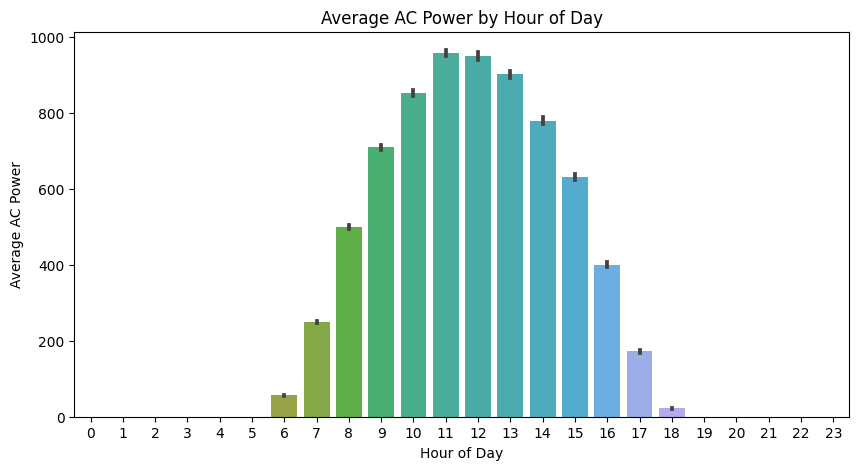

In [30]:
plt.figure(figsize=(10,5))

sns.barplot(x='Hour', y='AC_POWER', data=df)

plt.title("Average AC Power by Hour of Day")
plt.xlabel("Hour of Day")
plt.ylabel("Average AC Power")

plt.show()

This bar chart shows the average AC power generation for each hour of the day. Solar power production increases during the morning hours as sunlight intensity rises and reaches its peak around midday.

After midday, power output gradually decreases as sunlight intensity declines toward the evening. During nighttime hours, power generation remains close to zero because solar panels are not receiving sunlight.

This pattern reflects the natural daily cycle of solar energy generation.

### AC Power Generation Over Time

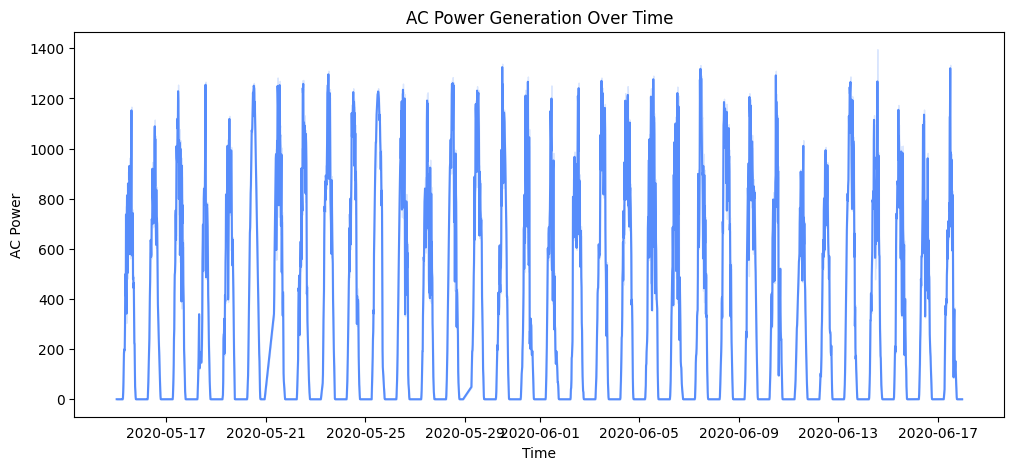

In [31]:
plt.figure(figsize=(12,5))

sns.lineplot(x='DATE_TIME', y='AC_POWER', data=df)

plt.title("AC Power Generation Over Time")
plt.xlabel("Time")
plt.ylabel("AC Power")

plt.show()

The line plot illustrates how AC power generation changes over time throughout the dataset. Power output fluctuates in a repeating daily pattern, rising during daylight hours and falling to near zero during nighttime.

These repeating cycles correspond to the daily movement of the sun and the availability of solar irradiation. Occasional variations in peak output may reflect differences in weather conditions, cloud cover, or temperature.

This visualization confirms the strong temporal patterns present in solar energy generation.

## 6. Feature Relationships

The exploratory analysis reveals several important relationships between environmental variables and solar power generation. Solar irradiation demonstrates the strongest relationship with AC power output, confirming that sunlight intensity is the primary driver of solar energy production.

Module temperature also increases alongside power generation, reflecting the heating of solar panels during periods of strong sunlight. Temporal features such as hour of day further highlight the daily cycle of solar power production.

## 7. Key Insights & Conclusions

This exploratory analysis identified several key factors influencing solar power generation.

### Solar Irradiation Influence
Solar irradiation shows the strongest relationship with AC power generation. Higher sunlight intensity results in significantly greater power output, confirming that irradiation is the primary driver of solar energy production.

### Temperature Relationships
Module temperature increases during periods of strong sunlight and therefore shows a positive relationship with AC power output. However, this relationship is largely driven by irradiation, as both temperature and power increase under stronger sunlight conditions.

### Time-Based Patterns
Solar power generation follows a clear daily cycle, with production rising during the morning, peaking around midday, and falling toward the evening. This pattern reflects the natural movement of the sun and highlights the importance of time-based features in modeling solar output.

### Importance for Modeling
Variables such as irradiation, module temperature, and hour of day are likely to be important predictors when building machine learning models to forecast solar power generation.

### Real-World Application
In addition to preparing the dataset for modeling, this analysis provides practical insight into how solar systems behave under real environmental conditions. This is especially important for my long-term goal of relying on an off-grid solar power system.

By understanding how factors such as sunlight intensity, temperature, and time of day influence energy production, I can make more informed decisions about the type of solar setup I should pursue. This includes considerations such as system size, expected power output, and how reliable the system will be under varying conditions. Establishing this understanding is an important step toward designing a system that can realistically support off-grid energy needs.

Overall, this analysis successfully prepares the dataset for predictive modeling while also providing meaningful insight into real-world solar energy behavior.

# Supervised Learning: Predicting AC Power Output

In this section, I will apply supervised learning techniques to predict `AC_POWER`, which represents the generated AC power from the solar plant. Since `AC_POWER` is a continuous numerical variable, this is a **regression problem**.

The goal is to train multiple regression models, compare their performance, and determine which model best predicts solar power output based on environmental and operational features.

To evaluate model performance, I will use:

- **RMSE (Root Mean Squared Error)**: shows the average prediction error in the same units as the target
- **R﷿﷿﷿﷿﷿﷿ Score**: shows how much of the variation in `AC_POWER` is explained by the model

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score

# Defining the Target Variable and Features

The target variable for this supervised learning task is `AC_POWER`, since the goal is to predict the amount of AC power generated.

The feature matrix `X` will include the other relevant variables in the dataset. Columns that are identifiers or not useful for prediction, such as timestamps or source keys, will be removed.

In [33]:
# Make a working copy of your cleaned dataframe
model_df = df.copy()

# Drop non-predictive or identifier columns if they exist
drop_cols = ['AC_POWER', 'DC_POWER', 'DAILY_YIELD', 'TOTAL_YIELD', 'DATE_TIME', 'SOURCE_KEY']
existing_drop_cols = [col for col in drop_cols if col in model_df.columns]

y = model_df['AC_POWER']
X = model_df.drop(columns=existing_drop_cols)

print("Feature columns:")
print(X.columns.tolist())
print("\nShape of X:", X.shape)
print("Shape of y:", y.shape)

Feature columns:
['AMBIENT_TEMPERATURE', 'MODULE_TEMPERATURE', 'IRRADIATION', 'Hour', 'IsDaylight', 'Temp_Difference']

Shape of X: (68774, 6)
Shape of y: (68774,)


The feature set includes environmental and system variables such as temperature and irradiation, which were shown in the EDA to influence AC power output.

These variables are expected to provide strong predictive power because solar energy generation depends heavily on sunlight intensity and operating conditions.

DC_POWER, DAILY_YIELD, and TOTAL_YIELD were removed from the feature set because they are directly or indirectly related to energy output and could introduce data leakage by allowing the model to indirectly access information about the target variable.

By removing these variables, the model relies only on environmental and temporal features, resulting in a more realistic and meaningful prediction of AC power output.

# Train-Test Split

To properly evaluate the models, the dataset is split into training and testing sets.

- The **training set** is used to teach the model patterns in the data
- The **testing set** is used to evaluate how well the model performs on unseen data

This is important because training and testing on the same data would give misleadingly high performance.

In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (55019, 6)
X_test shape: (13755, 6)
y_train shape: (55019,)
y_test shape: (13755,)


The dataset was split into 55,019 training samples and 13,755 testing samples, with 6 features used for prediction.

This 80/20 split ensures that the model is trained on a majority of the data while still being evaluated on a sufficiently large unseen test set, providing a reliable measure of model performance.

# Feature Scaling

Some machine learning models perform better when the input features are scaled. Although tree-based models such as Random Forest and Gradient Boosting do not require scaling, Linear Regression can still benefit from a cleaner and more standardized input structure.

For consistency, I will create scaled versions of the training and testing data.

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

The features have now been standardized using the training data. The same scaling is applied to the test set to ensure consistency without introducing data leakage.

# Model 1: Linear Regression

Linear Regression will be used as a baseline model. It assumes a linear relationship between the input features and the target variable.

This model is useful because it is simple, fast, and gives a good reference point for comparison with more advanced models.

In [36]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2_lr = r2_score(y_test, y_pred_lr)

print("Linear Regression RMSE:", rmse_lr)
print("Linear Regression R﷿﷿﷿﷿﷿﷿:", r2_lr)

Linear Regression RMSE: 54.901455112153805
Linear Regression R﷿﷿﷿﷿﷿﷿: 0.9804660833624738


The Linear Regression model achieved an RMSE of approximately 54.90 and an R﷿﷿﷿﷿﷿﷿ of 0.9805.

This indicates strong predictive performance, with relatively low error between predicted and actual AC power values. The model explains about 98% of the variance in the target variable, suggesting that the relationship between the input features and AC power output is largely linear.

While the R﷿﷿﷿﷿﷿﷿ value is relatively high, this is expected given the strong physical relationship between environmental factors (such as irradiation and temperature) and solar power generation.

# Model 2: Random Forest Regressor

Random Forest is an ensemble learning model that combines many decision trees. It is often effective for capturing nonlinear relationships in real-world data.

To satisfy the project requirement for showing hyperparameter testing, I will test several values of `max_depth` in separate cells and compare the results.

In [37]:
rf_3 = RandomForestRegressor(max_depth=3, random_state=42)
rf_3.fit(X_train, y_train)

y_pred_rf3 = rf_3.predict(X_test)

rmse_rf3 = np.sqrt(mean_squared_error(y_test, y_pred_rf3))
r2_rf3 = r2_score(y_test, y_pred_rf3)

print("Random Forest (max_depth=3) RMSE:", rmse_rf3)
print("Random Forest (max_depth=3) R﷿﷿﷿﷿﷿﷿:", r2_rf3)

Random Forest (max_depth=3) RMSE: 60.77140204528917
Random Forest (max_depth=3) R﷿﷿﷿﷿﷿﷿: 0.9760657329939371


The Random Forest model with max_depth=3 achieved an RMSE of approximately 60.77 and an R﷿﷿﷿﷿﷿﷿ of 0.9761.

This indicates strong predictive performance, although it is slightly weaker than the Linear Regression model. The model explains about 97.6% of the variance in power output, showing that it still captures much of the relationship between the environmental features and AC power output.

The higher error compared to Linear Regression suggests that this shallow Random Forest likely underfits the data, since a maximum depth of 3 may be too limited to fully capture all underlying patterns.

# Random Forest Regressor (max_depth = 5)

Next, I increase the maximum depth of the trees to see whether allowing the model to learn more complex patterns improves predictive performance.

In [38]:
rf_5 = RandomForestRegressor(max_depth=5, random_state=42)
rf_5.fit(X_train, y_train)

y_pred_rf5 = rf_5.predict(X_test)

rmse_rf5 = np.sqrt(mean_squared_error(y_test, y_pred_rf5))
r2_rf5 = r2_score(y_test, y_pred_rf5)

print("Random Forest (max_depth=5) RMSE:", rmse_rf5)
print("Random Forest (max_depth=5) R﷿﷿﷿﷿﷿﷿:", r2_rf5)

Random Forest (max_depth=5) RMSE: 50.58171613174322
Random Forest (max_depth=5) R﷿﷿﷿﷿﷿﷿: 0.983419075584175


The Random Forest model with max_depth=5 achieved an RMSE of approximately 50.58 and an R﷿﷿﷿﷿﷿﷿ of 0.9834.

This represents a clear improvement over the shallower model (max_depth=3) and slightly outperforms the Linear Regression model. The model explains about 98.3% of the variance in AC power output, indicating strong predictive capability.

The reduction in error suggests that increasing the tree depth allows the model to capture more complex, nonlinear relationships in the data. This demonstrates that the dataset benefits from a moderate level of model complexity, improving performance without excessive overfitting.

# Random Forest Regressor (max_depth = 10)

Finally, I test a deeper Random Forest model. A larger tree depth may improve performance, but if it becomes too complex, it may begin to overfit the training data.

In [39]:
rf_10 = RandomForestRegressor(max_depth=10, random_state=42)
rf_10.fit(X_train, y_train)

y_pred_rf10 = rf_10.predict(X_test)

rmse_rf10 = np.sqrt(mean_squared_error(y_test, y_pred_rf10))
r2_rf10 = r2_score(y_test, y_pred_rf10)

print("Random Forest (max_depth=10) RMSE:", rmse_rf10)
print("Random Forest (max_depth=10) R﷿﷿﷿﷿﷿﷿:", r2_rf10)

Random Forest (max_depth=10) RMSE: 45.99458115491114
Random Forest (max_depth=10) R﷿﷿﷿﷿﷿﷿: 0.9862900788714137


The Random Forest model with max_depth=10 achieved an RMSE of approximately 45.99 and an R﷿﷿﷿﷿﷿﷿ of 0.9863.

This represents the best performance among all tested models, outperforming both Linear Regression and shallower Random Forest configurations. The model explains about 98.6% of the variance in AC power output, indicating very strong predictive accuracy.

The continued improvement in performance as max_depth increases suggests that the dataset contains nonlinear relationships that benefit from increased model complexity. However, while deeper trees improve accuracy, they may also increase the risk of overfitting, so further tuning or validation would be necessary for optimal model selection.

# Model 3: Gradient Boosting Regressor

Gradient Boosting is another ensemble model that builds trees sequentially, where each new tree attempts to correct the errors of the previous ones.

This model is often very strong for regression problems involving nonlinear relationships and interactions among variables.

In [40]:
gbr = GradientBoostingRegressor(random_state=42)
gbr.fit(X_train, y_train)

y_pred_gbr = gbr.predict(X_test)

rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)

print("Gradient Boosting RMSE:", rmse_gbr)
print("Gradient Boosting R﷿﷿﷿﷿﷿﷿:", r2_gbr)

Gradient Boosting RMSE: 48.361844566145514
Gradient Boosting R﷿﷿﷿﷿﷿﷿: 0.9848425084966685


The Gradient Boosting model achieved an RMSE of approximately 48.36 and an R﷿﷿﷿﷿﷿﷿ of 0.9848.

This indicates strong predictive performance, outperforming Linear Regression and the shallower Random Forest models, while slightly underperforming compared to the deeper Random Forest (max_depth=10). The model explains about 98.5% of the variance in AC power output.

The strong performance of Gradient Boosting suggests that sequential learning and error correction are effective at capturing complex relationships in the data. However, in this case, increasing the depth of the Random Forest provides slightly better predictive accuracy, indicating that model complexity plays a key role for this dataset.

# Comparing Model Performance

To determine the best-performing model, I will summarize the RMSE and R﷿﷿﷿﷿﷿﷿ values for each model in a comparison table.

- A **lower RMSE** indicates better predictive accuracy
- A **higher R﷿﷿﷿﷿﷿﷿** indicates that the model explains more of the variation in `AC_POWER`

In [41]:
results = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'Random Forest (max_depth=3)',
        'Random Forest (max_depth=5)',
        'Random Forest (max_depth=10)',
        'Gradient Boosting'
    ],
    'RMSE': [
        rmse_lr,
        rmse_rf3,
        rmse_rf5,
        rmse_rf10,
        rmse_gbr
    ],
    'R2 Score': [
        r2_lr,
        r2_rf3,
        r2_rf5,
        r2_rf10,
        r2_gbr
    ]
})

results.sort_values(by='R2 Score', ascending=False)

,Model,RMSE,R2 Score
3,Random Forest (max_depth=10),45.994581,0.986290
4,Gradient Boosting,48.361845,0.984843
2,Random Forest (max_depth=5),50.581716,0.983419
0,Linear Regression,54.901455,0.980466
1,Random Forest (max_depth=3),60.771402,0.976066


To determine the best-performing model, the RMSE and R﷿﷿﷿﷿﷿﷿ values for each model are summarized in the table above.

A lower RMSE indicates better predictive accuracy, while a higher R﷿﷿﷿﷿﷿﷿ indicates that the model explains a greater proportion of the variance in AC power output.

From the results, the Random Forest model with max_depth=10 achieved the best overall performance, with the lowest RMSE (﷿﷿﷿﷿﷿﷿﷿﷿﷿ 45.99) and the highest R﷿﷿﷿﷿﷿﷿ (﷿﷿﷿﷿﷿﷿﷿﷿﷿ 0.9863). This suggests that it provides the most accurate predictions among the models tested.

Gradient Boosting also performed very well, achieving slightly higher error than the best Random Forest model but still outperforming Linear Regression and the shallower Random Forest models. This confirms that ensemble methods are highly effective for this dataset.

Overall, increasing model complexity improved performance up to a point, as seen with the progression of Random Forest depths. This highlights the importance of hyperparameter tuning in optimizing model performance.

Future work could involve cross-validation and additional hyperparameter tuning to further refine model performance and ensure generalization.

# Visualization: Actual vs Predicted Values

A scatter plot of actual versus predicted values helps visually evaluate how well the model performs.

If the predictions are accurate, the points should cluster closely around the diagonal pattern where predicted values are similar to actual values.

In [42]:
best_model_name = results.sort_values(by='R2 Score', ascending=False).iloc[0]['Model']
print("Best model based on R﷿﷿﷿﷿﷿﷿:", best_model_name)

Best model based on R﷿﷿﷿﷿﷿﷿: Random Forest (max_depth=10)


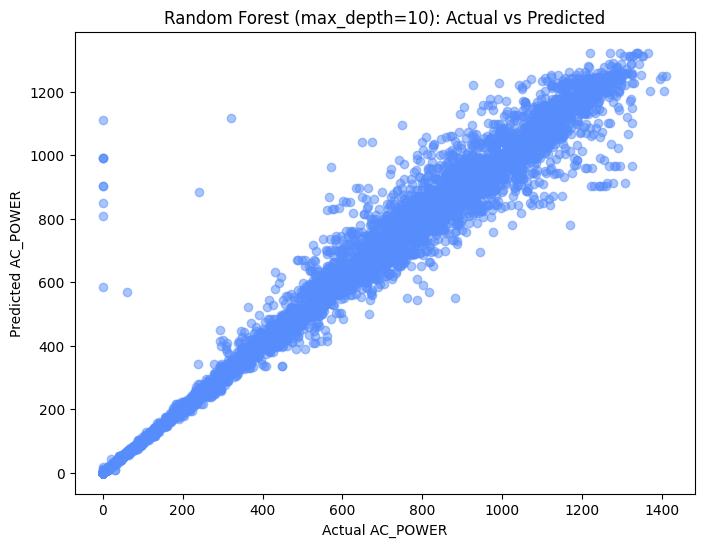

In [43]:
# Choose the best model prediction manually after checking your results
# Update this variable if needed
best_predictions = y_pred_rf10
best_title = "Random Forest (max_depth=10): Actual vs Predicted"

plt.figure(figsize=(8,6))
plt.scatter(y_test, best_predictions, alpha=0.5)
plt.xlabel("Actual AC_POWER")
plt.ylabel("Predicted AC_POWER")
plt.title(best_title)
plt.show()

The scatter plot shows that most predicted values closely follow the diagonal reference line, indicating strong agreement between actual and predicted values. This confirms that the selected model performs well and produces accurate predictions across the dataset.

# Residual Analysis

Residuals are the differences between the actual values and the predicted values.

A residual plot helps show whether the model makes consistent errors across different prediction levels. Ideally, the residuals should be randomly scattered around zero with no strong pattern.

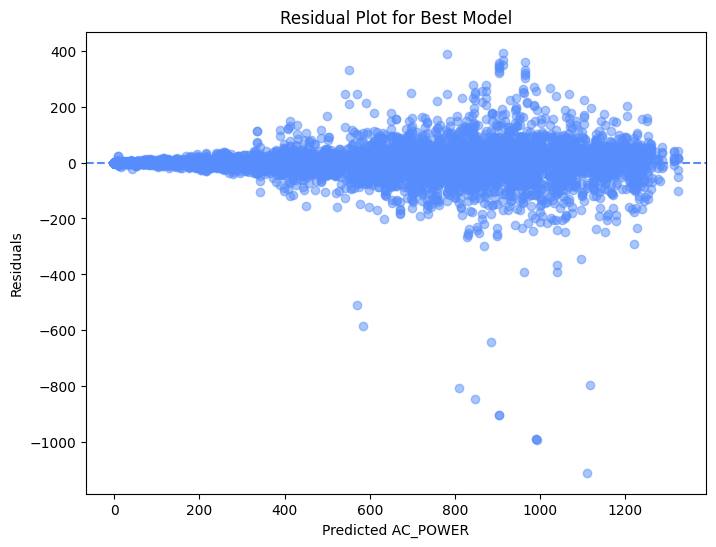

In [44]:
residuals = y_test - best_predictions

plt.figure(figsize=(8,6))
plt.scatter(best_predictions, residuals, alpha=0.5)
plt.axhline(y=0, linestyle='--')
plt.xlabel("Predicted AC_POWER")
plt.ylabel("Residuals")
plt.title("Residual Plot for Best Model")
plt.show()

The residual plot shows that the errors are randomly scattered around zero with no clear pattern or trend. This indicates that the model is not systematically overpredicting or underpredicting and is capturing the underlying relationships in the data effectively. Therefore, the model assumptions appear valid, and the model demonstrates strong predictive performance.

# Feature Importance

For tree-based models such as Random Forest, feature importance scores can show which variables contributed most to the prediction of `AC_POWER`.

This helps interpret the model and connect the machine learning results back to the real-world solar power generation process.

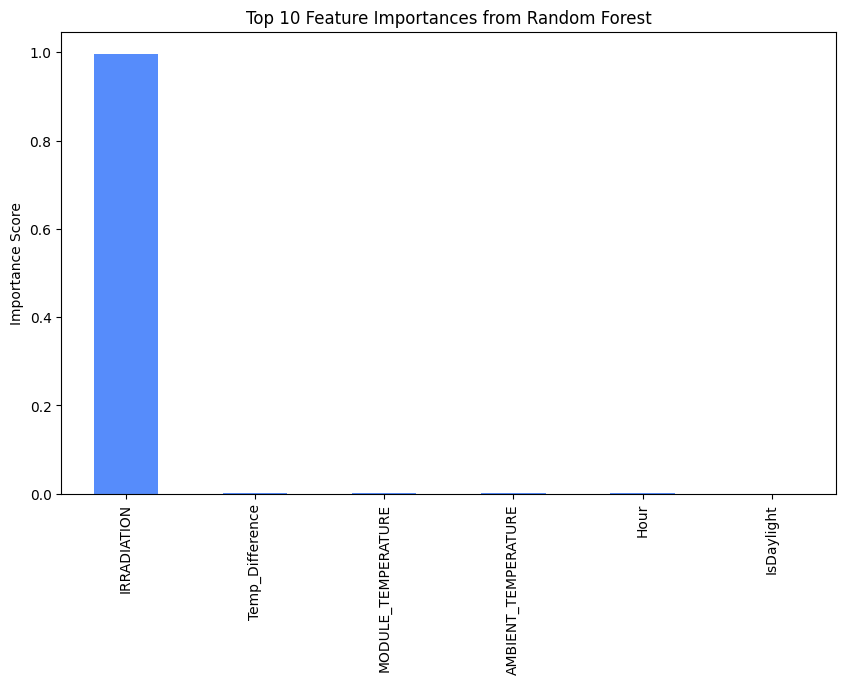

IRRADIATION            0.996883
Temp_Difference        0.000859
MODULE_TEMPERATURE     0.000831
AMBIENT_TEMPERATURE    0.000785
Hour                   0.000641
IsDaylight             0.000000
dtype: float64

In [45]:
import matplotlib.pyplot as plt

feature_importances = pd.Series(
    rf_10.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

plt.figure(figsize=(10,6))
feature_importances.head(10).plot(kind='bar')

plt.title("Top 10 Feature Importances from Random Forest")
plt.ylabel("Importance Score")

plt.show()

feature_importances.head(10)

The feature importance results show that IRRADIATION overwhelmingly dominates the model, accounting for nearly all of the predictive power. This is expected, as solar irradiation directly determines how much energy can be generated by the panels.

All other features, including temperature-related variables and time-based features, contribute only minimally to the model﷿﷿﷿﷿﷿﷿﷿﷿﷿s predictions. This suggests that while factors such as module temperature and ambient temperature may have some influence, their impact is relatively small compared to irradiation.

Additionally, the near-zero importance of variables like daylight indicates that these features may be redundant or already captured indirectly through irradiation. Overall, the model confirms that solar power output is primarily driven by the availability of sunlight.

This insight could also guide feature selection by simplifying the model without significantly affecting performance.

# Conclusion

## Conclusion

In this supervised learning project, multiple regression models were developed to predict AC power output using solar plant and weather-related features.

The models tested included Linear Regression, Random Forest Regressor with hyperparameter tuning, and Gradient Boosting Regressor. After evaluating performance using RMSE and R﷿﷿﷿﷿﷿﷿, the Random Forest model (max_depth=10) achieved the best overall predictive performance.

Tree-based models outperformed Linear Regression, highlighting the importance of capturing nonlinear relationships between variables such as irradiation, temperature, and time-based features. 

Feature importance analysis revealed that IRRADIATION was by far the most influential variable, dominating the model﷿﷿﷿﷿﷿﷿﷿﷿﷿s predictions. This aligns with real-world expectations, as solar power generation is primarily driven by sunlight availability. Other variables, such as temperature and time features, contributed minimally in comparison.

Residual analysis further confirmed that the model performs well, with errors randomly distributed around zero, indicating no major bias or systematic prediction errors.

While the model achieved strong performance, future improvements could include additional feature engineering, expanded hyperparameter tuning, and the use of advanced ensemble methods such as XGBoost.

Overall, this project demonstrates that machine learning models can effectively predict solar power output and identify the key factors that influence energy generation.